In [ ]:
# Uninstall everything potentially conflicting
!pip -q uninstall -y transformers tokenizers accelerate peft bitsandbytes trl huggingface_hub datasets

# Clean install of the latest versions
!pip -q install transformers tokenizers accelerate peft bitsandbytes trl datasets sentencepiece

print('Install done. RESTART THE RUNTIME NOW: Runtime menu -> Restart session')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 162.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 49.8 MB/s eta 0:00:00
Install done. RESTART THE RUNTIME NOW: Runtime menu -> Restart session


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, gc, random, re
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# EDIT THESE
JSONL_PATH = '/content/drive/MyDrive/Colab Notebooks/out_features.jsonl'
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/llm_training'
HF_TOKEN   = ''  # paste your Hugging Face token (needed for gated Llama models)

Path(OUTPUT_DIR, 'checkpoints').mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR, 'results').mkdir(parents=True, exist_ok=True)

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN)

random.seed(42); np.random.seed(42); torch.manual_seed(42)

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Mounted at /content/drive
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
DROPPED_MEASUREMENTS = {
    'visible_text_length', 'internal_nav_candidate_count', 'anchor_count',
    'external_anchor_count', 'script_src_sample_count', 'image_src_sample_count',
    'stylesheet_href_sample_count', 'favicon_count', 'contact_anchor_domains',
}

# Load full data, sample 5000 phishing + 5000 benign
all_records = []
with open(JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='loading'):
        try: r = json.loads(line)
        except: continue
        if (r.get('label') or '').lower() in ('phishing','benign'):
            all_records.append(r)

random.shuffle(all_records)
phish  = [r for r in all_records if r['label']=='phishing'][:5000]
benign = [r for r in all_records if r['label']=='benign'][:5000]
sample = phish + benign
random.shuffle(sample)
print(f'Sampled {len(sample):,} records  ({len(phish)} phish + {len(benign)} benign)')


# ---------------------------------------------------------------------------
# Better system prompt — explicit about the task, the signals, and the format
# ---------------------------------------------------------------------------
SYSTEM_PROMPT = (
    "You are a security analyst that classifies web pages as either phishing or benign. "
    "You will be given structured information about a page: its URL, page title, basic "
    "measurements, and a list of automatically detected signals. Each signal has a direction "
    "(suspicious, benign, or uncertain) and a severity (low, medium, high).\n\n"
    "Your task is to:\n"
    "1. Decide whether the page is phishing or benign.\n"
    "2. Justify your decision by citing the specific detected signals from the input. "
    "Do not invent signals that were not provided. Reference the signals' actual content, "
    "not just their names. If the page is benign, explain what protected it from being "
    "classified as phishing (e.g., absence of credential collection, presence of legitimate "
    "navigation, matching identity signals). If phishing, name the suspicious patterns you "
    "saw and why they matter.\n\n"
    "Respond in this exact format:\n"
    "Verdict: <phishing|benign>\n"
    "Explanation: <2-4 sentences referencing the specific signals you used>"
)


def verbalize_record(r):
    """Build a natural-language description of a URL from its features."""
    inp   = r.get('input') or {}
    meas  = r.get('measurements') or {}
    feats = r.get('features') or []

    lines = [f"URL: {inp.get('url','(missing)')}"]
    if inp.get('title'):
        lines.append(f"Page title: {inp['title']}")

    keep_meas = {k: v for k, v in meas.items()
                 if k not in DROPPED_MEASUREMENTS and not isinstance(v, (list, dict))}
    if 'final_hostname' in keep_meas:
        lines.append(f"Hostname: {keep_meas['final_hostname']}")
    summary_keys = ['url_length','hostname_label_count','redirect_count','form_count',
                    'credential_form_count','password_input_count','hidden_input_count',
                    'external_anchor_ratio','null_anchor_count']
    parts = [f"{k}={keep_meas[k]}" for k in summary_keys if k in keep_meas]
    if parts:
        lines.append("Page measurements: " + ", ".join(parts))

    if feats:
        lines.append("Detected signals:")
        for fo in feats:
            stmt      = fo.get('statement') or fo.get('id') or ''
            direction = fo.get('direction','')
            severity  = fo.get('severity','')
            tag = f"[{direction}/{severity}]" if direction else ""
            lines.append(f"  {tag} {stmt}")
    else:
        lines.append("Detected signals: (none)")

    return "\n".join(lines)


def build_prompt(r):
    return f"{SYSTEM_PROMPT}\n\n---\n{verbalize_record(r)}"


# ---------------------------------------------------------------------------
# Grounded target explanation — uses the actual fired features for THIS url
# ---------------------------------------------------------------------------
def _pick_features(feats, direction=None, max_n=4):
    """Pick up to max_n features matching direction (or any if direction=None),
    sorted by severity (high → low)."""
    sev = {'high':0,'medium':1,'low':2,'':3}
    pool = [f for f in feats if (direction is None or f.get('direction')==direction)]
    pool = sorted(pool, key=lambda f: sev.get(f.get('severity',''), 3))
    return [f for f in pool[:max_n] if f.get('statement')]


def build_target(r):
    """Generate a per-URL explanation that actually cites the features that fired."""
    label = r['label']
    feats = r.get('features') or []

    suspicious = _pick_features(feats, 'suspicious', max_n=4)
    benignish  = _pick_features(feats, 'benign',     max_n=3)
    uncertain  = _pick_features(feats, 'uncertain',  max_n=2)

    if label == 'phishing':
        # Cite up to 4 suspicious signals (their actual statements).
        # If a strong benign-direction signal also fired, briefly acknowledge it
        # was outweighed by the suspicious signals.
        if suspicious:
            cites = " ".join(f.get('statement','').rstrip('.') + '.'
                             for f in suspicious[:3])
            if benignish:
                tail = (f" Although there is a benign-direction signal "
                        f"({benignish[0]['statement'].rstrip('.').lower()}), "
                        f"the suspicious indicators dominate the assessment.")
            elif uncertain:
                tail = (f" The page also shows an uncertain pattern: "
                        f"{uncertain[0]['statement'].rstrip('.').lower()}.")
            else:
                tail = ""
            expl = f"This page exhibits multiple phishing indicators. {cites}{tail}"
        else:
            expl = ("Although no high-severity signals fired, the combination of weaker "
                    "indicators and the absence of legitimacy markers suggests phishing.")
    else:  # benign
        # Cite the legitimate signals AND/OR the absence of strong suspicious ones.
        if benignish:
            cites = " ".join(f.get('statement','').rstrip('.') + '.'
                             for f in benignish[:2])
            if suspicious:
                tail = (f" While weaker suspicious signals were observed "
                        f"(e.g., {suspicious[0]['statement'].rstrip('.').lower()}), "
                        f"they are insufficient on their own and the legitimate signals "
                        f"are stronger.")
            else:
                tail = ""
            expl = f"This page appears legitimate. {cites}{tail}"
        elif suspicious:
            # benign label but only suspicious signals fired — explain why we still call it benign
            cites = ", ".join(f.get('statement','').rstrip('.').lower()
                              for f in suspicious[:2])
            expl = (f"The page shows weak suspicious patterns ({cites}), but lacks the "
                    f"strong markers of phishing such as credential collection on a "
                    f"mismatched-brand domain, coercive urgency, or brand impersonation. "
                    f"On balance, the page is benign.")
        else:
            expl = ("No phishing-direction signals fired and the page structure is "
                    "consistent with a legitimate site.")

    return f"Verdict: {label}\nExplanation: {expl}"


# Build the dataset
rows = []
for r in sample:
    rows.append({
        'id': r.get('id'),
        'label': r['label'],
        'url': (r.get('input') or {}).get('url',''),
        'fired_features_full': r.get('features') or [],   # keep full feature objects
        'fired_feature_ids':   [f.get('id') for f in (r.get('features') or []) if f.get('id')],
        'prompt': build_prompt(r),
        'target': build_target(r),
    })
df = pd.DataFrame(rows)
print(f'Built {len(df):,} prompt/target pairs')

print('\n' + '='*70 + '\nEXAMPLE — PHISHING\n' + '='*70)
ex = df[df['label']=='phishing'].iloc[0]
print(ex['prompt'][:1500])
print('-' * 60)
print('TARGET:')
print(ex['target'])

print('\n' + '='*70 + '\nEXAMPLE — BENIGN\n' + '='*70)
ex = df[df['label']=='benign'].iloc[0]
print(ex['prompt'][:1500])
print('-' * 60)
print('TARGET:')
print(ex['target'])

loading: 0it [00:00, ?it/s]

Sampled 10,000 records  (5000 phish + 5000 benign)
Built 10,000 prompt/target pairs

EXAMPLE — PHISHING
You are a security analyst that classifies web pages as either phishing or benign. You will be given structured information about a page: its URL, page title, basic measurements, and a list of automatically detected signals. Each signal has a direction (suspicious, benign, or uncertain) and a severity (low, medium, high).

Your task is to:
1. Decide whether the page is phishing or benign.
2. Justify your decision by citing the specific detected signals from the input. Do not invent signals that were not provided. Reference the signals' actual content, not just their names. If the page is benign, explain what protected it from being classified as phishing (e.g., absence of credential collection, presence of legitimate navigation, matching identity signals). If phishing, name the suspicious patterns you saw and why they matter.

Respond in this exact format:
Verdict: <phishing|benign>


In [ ]:
from sklearn.model_selection import train_test_split

train_df, tmp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df['label'], random_state=42)

print(f'train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')
for name, d in [('train',train_df),('val',val_df),('test',test_df)]:
    print(f'  {name}: {dict(d["label"].value_counts())}')

# Save splits
train_df[['id','label','url','prompt','target']].to_json(
    Path(OUTPUT_DIR,'train.jsonl'), orient='records', lines=True)
val_df[['id','label','url','prompt','target']].to_json(
    Path(OUTPUT_DIR,'val.jsonl'),   orient='records', lines=True)
test_df[['id','label','url','prompt','target']].to_json(
    Path(OUTPUT_DIR,'test.jsonl'),  orient='records', lines=True)

train: 7,000  val: 1,500  test: 1,500
  train: {'phishing': np.int64(3500), 'benign': np.int64(3500)}
  val: {'phishing': np.int64(750), 'benign': np.int64(750)}
  test: {'benign': np.int64(750), 'phishing': np.int64(750)}


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from datasets import Dataset
from trl import SFTTrainer, SFTConfig


def train_model(model_id, run_name, train_df, val_df, epochs=2, max_steps=None):
    print(f'\n{"="*60}\nTraining {run_name}: {model_id}  (epochs={epochs})\n{"="*60}')

    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                             bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    tok.padding_side = 'right'

    model = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=bnb, device_map='auto', dtype=torch.bfloat16)
    model = prepare_model_for_kbit_training(model)

    lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias='none',
                      task_type='CAUSAL_LM',
                      target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'])
    model = get_peft_model(model, lora)
    model.print_trainable_parameters()

    def fmt(row):
        prompt = tok.apply_chat_template(
            [{'role':'user','content': row['prompt']}],
            tokenize=False, add_generation_prompt=True)
        completion = row['target'] + tok.eos_token
        return {'prompt': prompt, 'completion': completion}

    train_ds = Dataset.from_pandas(train_df[['prompt','target']]).map(
        fmt, remove_columns=['prompt','target'])
    val_ds   = Dataset.from_pandas(val_df[['prompt','target']]).map(
        fmt, remove_columns=['prompt','target'])

    out_dir = Path(OUTPUT_DIR,'checkpoints',run_name)
    cfg = SFTConfig(
        output_dir=str(out_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_steps=50,
        lr_scheduler_type='cosine',
        logging_steps=20,
        eval_strategy='steps', eval_steps=100,
        save_strategy='steps', save_steps=200,
        save_total_limit=2,
        bf16=True,
        report_to='none',
        max_steps=max_steps if max_steps else -1,
        gradient_checkpointing=True,
        max_length=2048,
        completion_only_loss=True,
    )

    try:
        trainer = SFTTrainer(model=model, processing_class=tok,
                             train_dataset=train_ds, eval_dataset=val_ds, args=cfg)
    except TypeError:
        trainer = SFTTrainer(model=model, tokenizer=tok,
                             train_dataset=train_ds, eval_dataset=val_ds, args=cfg)

    trainer.train()
    trainer.save_model(str(out_dir/'final'))
    tok.save_pretrained(str(out_dir/'final'))

    del model, trainer; gc.collect(); torch.cuda.empty_cache()
    print(f'Saved to {out_dir/"final"}')
    return str(out_dir/'final'), model_id

In [ ]:
from huggingface_hub import login
login(token="HUGGINGFACE_TOKEN_REMOVED")

In [ ]:
adapter_3b, base_3b = train_model(
    model_id='meta-llama/Llama-3.2-3B-Instruct',
    run_name='llama32_3b',
    train_df=train_df, val_df=val_df,
    epochs=3)


Training llama32_3b: meta-llama/Llama-3.2-3B-Instruct  (epochs=3)


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Adding EOS to eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss,Validation Loss
100,0.007766,0.005998
200,0.004752,0.003133
300,0.002555,0.002379
400,0.000651,0.001636
500,0.001995,0.001190
600,0.001194,0.001346
700,0.000435,0.001023
800,0.000856,0.001049
900,0.000225,0.000967
1000,0.000186,0.000935


Saved to /content/drive/MyDrive/Colab Notebooks/llm_training/checkpoints/llama32_3b/final


In [ ]:
adapter_8b, base_8b = train_model(
    model_id='meta-llama/Llama-3.1-8B-Instruct',
    run_name='llama31_8b',
    train_df=train_df, val_df=val_df,
    epochs=5)


Training llama31_8b: meta-llama/Llama-3.1-8B-Instruct  (epochs=5)


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Tokenizing eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Step,Training Loss,Validation Loss
100,0.004923,0.004047
200,0.003873,0.002455
300,0.002184,0.001549
400,0.003794,0.009867
500,0.001763,0.001455
600,0.001421,0.001092
700,0.001135,0.001175
800,0.000808,0.001847
900,0.000195,0.000594
1000,0.000031,0.000618


Step,Training Loss,Validation Loss
100,0.004923,0.004047
200,0.003873,0.002455
300,0.002184,0.001549
400,0.003794,0.009867
500,0.001763,0.001455
600,0.001421,0.001092
700,0.001135,0.001175
800,0.000808,0.001847
900,0.000195,0.000594
1000,0.000031,0.000618


Saved to /content/drive/MyDrive/Colab Notebooks/llm_training/checkpoints/llama31_8b/final


In [12]:
def load_for_inference(base_id, adapter_path):
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                             bnb_4bit_compute_dtype=torch.bfloat16)
    tok = AutoTokenizer.from_pretrained(adapter_path)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    tok.padding_side = 'left'
    model = AutoModelForCausalLM.from_pretrained(base_id, quantization_config=bnb,
                                                 device_map='auto', dtype=torch.bfloat16)
    model = PeftModel.from_pretrained(model, adapter_path)
    model.eval()
    return model, tok


@torch.no_grad()
def predict(model, tok, prompts, batch_size=8, max_new=220):
    outs = []
    for i in tqdm(range(0, len(prompts), batch_size), desc='generating'):
        batch = prompts[i:i+batch_size]
        msgs  = [[{'role':'user','content':p}] for p in batch]
        texts = [tok.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in msgs]
        enc   = tok(texts, return_tensors='pt', padding=True, truncation=True, max_length=2048).to(model.device)
        gen   = model.generate(**enc, max_new_tokens=max_new, do_sample=False,
                               pad_token_id=tok.pad_token_id, temperature=1.0, top_p=1.0)
        for j, full in enumerate(gen):
            new = full[enc.input_ids.shape[1]:]
            outs.append(tok.decode(new, skip_special_tokens=True).strip())
    return outs


def parse_output(text):
    verdict = None
    m = re.search(r'verdict\s*[:\-]\s*(phishing|benign)', text, re.IGNORECASE)
    if m: verdict = m.group(1).lower()
    elif re.search(r'\bphishing\b', text, re.IGNORECASE): verdict = 'phishing'
    elif re.search(r'\bbenign\b',   text, re.IGNORECASE): verdict = 'benign'
    exp = ''
    m = re.search(r'explanation\s*[:\-]\s*(.+)', text, re.IGNORECASE | re.DOTALL)
    if m: exp = m.group(1).strip()
    else: exp = text.strip()
    return verdict, exp


prompts_test = test_df['prompt'].tolist()

print('--- Llama 3.2 3B inference ---')
m3b, t3b = load_for_inference(base_3b, adapter_3b)
raw_3b   = predict(m3b, t3b, prompts_test, batch_size=8)
del m3b; gc.collect(); torch.cuda.empty_cache()

print('--- Llama 3.1 8B inference ---')
m8b, t8b = load_for_inference(base_8b, adapter_8b)
raw_8b   = predict(m8b, t8b, prompts_test, batch_size=4)
del m8b; gc.collect(); torch.cuda.empty_cache()

test_df = test_df.reset_index(drop=True).copy()
test_df['raw_3b'] = raw_3b
test_df['raw_8b'] = raw_8b
test_df[['pred_3b','exp_3b']] = pd.DataFrame([parse_output(t) for t in raw_3b], index=test_df.index)
test_df[['pred_8b','exp_8b']] = pd.DataFrame([parse_output(t) for t in raw_8b], index=test_df.index)

# Save (drop the heavy fired_features_full column from disk to keep file small)
test_df.drop(columns=['fired_features_full']).to_json(
    Path(OUTPUT_DIR,'results','test_predictions.jsonl'),
    orient='records', lines=True)
print('Saved predictions.')

--- Llama 3.2 3B inference ---


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generating:   0%|          | 0/188 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


--- Llama 3.1 8B inference ---


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generating:   0%|          | 0/375 [00:00<?, ?it/s]

Saved predictions.



=== Llama 3.2 3B ===
  parsed: 1500/1500
  F1: 0.9746
  acc: 0.9747
              precision    recall  f1-score   support

      benign       0.97      0.98      0.97       750
    phishing       0.98      0.97      0.97       750

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500

confusion matrix [rows=true, cols=pred]
          benign  phishing
benign       734        16
phishing      22       728

=== Llama 3.1 8B ===
  parsed: 1500/1500
  F1: 0.9866
  acc: 0.9867
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99       750
    phishing       0.99      0.98      0.99       750

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500

confusion matrix [rows=true, cols=pred]
          benign  phishing
benign       745    

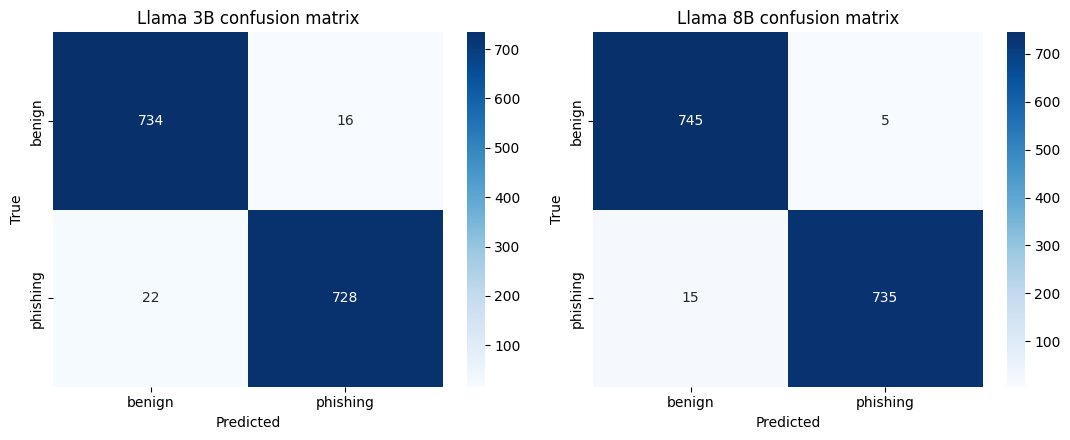

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(y_true, y_pred, name):
    valid = [(t,p) for t,p in zip(y_true, y_pred) if p in ('phishing','benign')]
    yt = [v[0] for v in valid]; yp = [v[1] for v in valid]
    print(f'\n=== {name} ===')
    print(f'  parsed: {len(valid)}/{len(y_true)}')
    print(f'  F1: {f1_score(yt, yp, pos_label="phishing"):.4f}')
    print(f'  acc: {accuracy_score(yt, yp):.4f}')
    print(classification_report(yt, yp, labels=['benign','phishing']))
    cm = confusion_matrix(yt, yp, labels=['benign','phishing'])
    print('confusion matrix [rows=true, cols=pred]')
    print(pd.DataFrame(cm, index=['benign','phishing'], columns=['benign','phishing']))
    return cm

cm_3b = evaluate(test_df['label'].tolist(), test_df['pred_3b'].tolist(), 'Llama 3.2 3B')
cm_8b = evaluate(test_df['label'].tolist(), test_df['pred_8b'].tolist(), 'Llama 3.1 8B')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, name in [(axes[0], cm_3b, '3B'), (axes[1], cm_8b, '8B')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['benign','phishing'], yticklabels=['benign','phishing'])
    ax.set_title(f'Llama {name} confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR,'results','confusion_matrices.png'), dpi=140)
plt.show()

In [14]:
FEATURE_KEYWORDS = {
    'meta.robots_noindex_nofollow':              ['noindex','nofollow','robots','indexed','search engine'],
    'credential.password_input_present':         ['password','credential'],
    'credential.credential_terms_near_form':     ['credential','login form','sign in','username','email'],
    'form.empty_or_blank_action':                ['empty action','blank action','no action','form action'],
    'form.blank_action_js_submission_suspected': ['javascript','js submission','blank action'],
    'form.hidden_inputs':                        ['hidden input','hidden field'],
    'form.action_same_org_domain':               ['same domain','same organization','form action'],
    'form.external_action':                      ['external action','different domain','external form'],
    'brand.title_domain_mismatch':               ['title','brand','mismatch','impersonat','claim','outlook','microsoft','google','apple','paypal','amazon'],
    'brand.title_domain_match_strong':           ['title matches','brand match','legitimate brand'],
    'brand.favicon_domain_mismatch':             ['favicon','icon','mismatch'],
    'brand.domain_lookalike':                    ['lookalike','typosquat','homoglyph','similar domain'],
    'link.null_or_void_anchors':                 ['null link','void link','empty link','dead link'],
    'link.brand_text_domain_mismatch':           ['link text','anchor text','brand text','mismatch'],
    'link.high_external_anchor_ratio':           ['external link','outgoing link','external anchor'],
    'login.missing_recovery_or_help_flow':       ['recovery','forgot password','help','support link','reset','register'],
    'page.generic_login_without_brand_claim':    ['generic login','no brand','unbranded'],
    'page.interstitial_without_credential_collection': ['interstitial','landing page','no credential'],
    'page.low_semantic_content':                 ['low content','little text','minimal content','sparse'],
    'page.rendering_incomplete_or_script_dependent':   ['incomplete','rendering','script','javascript'],
    'iframe.hidden_iframe':                      ['iframe','hidden frame'],
    'navigation.functional_internal_links':      ['navigation','menu','internal link'],
    'support.contact_domain_match':              ['contact','support','same domain'],
    'contact.identity_domain_mismatch':          ['contact','identity','mismatch'],
    'redirect.multi_hop':                        ['redirect','multiple redirects','redirect chain'],
    'redirect.cross_domain':                     ['cross-domain','redirect','different domain'],
    'url.deep_subdomain':                        ['subdomain','deep subdomain','many subdomain'],
    'url.long_url':                              ['long url','url length'],
    'url.http_not_https':                        ['http ','not https','http://','insecure','no ssl','no tls'],
    'url.email_identifier':                      ['email','@ symbol','email in url'],
    'url.homograph_or_unicode_hostname':         ['homograph','unicode','idn','punycode'],
    'content.copyright_domain_mismatch':         ['copyright','footer','mismatch'],
    'content.coercive_urgency_near_form':        ['urgency','urgent','immediately','suspend','verify now','24 hours'],
    'content.non_credential_transactional_page': ['transactional','checkout','payment'],
    'content.file_lure_terms':                   ['file','download','attachment','document'],
    'identity.provider_expected_domain':         ['identity provider','sso','expected domain'],
}


def explanation_mentions_feature(exp, feat_id):
    if not exp: return False
    kws = FEATURE_KEYWORDS.get(feat_id, [feat_id.split('.')[-1].replace('_',' ')])
    exp_l = exp.lower()
    return any(kw.lower() in exp_l for kw in kws)


def faithfulness_metrics(row, exp_col):
    fired = set(row['fired_feature_ids'])
    if not fired: return None
    exp = row[exp_col] or ''
    mentioned = {fid for fid in fired if explanation_mentions_feature(exp, fid)}
    plausible = {fid for fid in FEATURE_KEYWORDS if explanation_mentions_feature(exp, fid)}
    recall    = len(mentioned) / len(fired) if fired else 0.0
    precision = (len(mentioned) / len(plausible)) if plausible else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
    return precision, recall, f1


for col, name in [('exp_3b','3B'), ('exp_8b','8B')]:
    metrics = test_df.apply(lambda r: faithfulness_metrics(r, col), axis=1)
    valid   = [m for m in metrics if m is not None]
    if valid:
        arr = np.array(valid)
        print(f'\n{name} faithfulness ({len(valid)} URLs with fired features):')
        print(f'  precision: {arr[:,0].mean():.3f}')
        print(f'  recall:    {arr[:,1].mean():.3f}')
        print(f'  F1:        {arr[:,2].mean():.3f}')
        test_df[f'faith_p_{name}'] = [m[0] if m else None for m in metrics]
        test_df[f'faith_r_{name}'] = [m[1] if m else None for m in metrics]
        test_df[f'faith_f_{name}'] = [m[2] if m else None for m in metrics]


3B faithfulness (1418 URLs with fired features):
  precision: 0.714
  recall:    0.639
  F1:        0.648

8B faithfulness (1418 URLs with fired features):
  precision: 0.712
  recall:    0.639
  F1:        0.646


In [15]:
def show(row, model='3b'):
    print('='*70)
    print(f'URL:        {row["url"][:120]}')
    print(f'True label: {row["label"]}')
    print(f'Predicted:  {row[f"pred_{model}"]}   |   correct: {row[f"pred_{model}"]==row["label"]}')
    print(f'\nFired features ({len(row["fired_features_full"])}):')
    for fo in row['fired_features_full'][:8]:
        fid       = fo.get('id','?')
        direction = fo.get('direction','?')
        severity  = fo.get('severity','?')
        stmt      = (fo.get('statement') or '').strip()
        print(f'  - [{direction}/{severity}] {fid}')
        if stmt: print(f'      → "{stmt[:140]}"')
    print(f'\nModel explanation:')
    print(f'  {row[f"exp_{model}"]}')
    if f'faith_f_{model.upper()}' in row.index and row.get(f'faith_f_{model.upper()}') is not None:
        print(f'\nFaithfulness  P={row[f"faith_p_{model.upper()}"]:.2f}  '
              f'R={row[f"faith_r_{model.upper()}"]:.2f}  '
              f'F1={row[f"faith_f_{model.upper()}"]:.2f}')


print('\n\n###### LLAMA 3B EXAMPLES ######')
correct = test_df[test_df['pred_3b']==test_df['label']].head(3)
wrong   = test_df[(test_df['pred_3b']!=test_df['label']) &
                  test_df['pred_3b'].isin(['phishing','benign'])].head(2)
for _, r in pd.concat([correct, wrong]).iterrows(): show(r, '3b')

print('\n\n###### LLAMA 8B EXAMPLES ######')
correct = test_df[test_df['pred_8b']==test_df['label']].head(3)
wrong   = test_df[(test_df['pred_8b']!=test_df['label']) &
                  test_df['pred_8b'].isin(['phishing','benign'])].head(2)
for _, r in pd.concat([correct, wrong]).iterrows(): show(r, '8b')



###### LLAMA 3B EXAMPLES ######
URL:        https://hostit.pl/
True label: benign
Predicted:  benign   |   correct: True

Fired features (3):
  - [suspicious/low] link.null_or_void_anchors
      → "Page includes 1 null or void link(s)."
  - [suspicious/low] link.brand_text_domain_mismatch
      → "Link text suggests google, but the link points to hostit.pl."
  - [benign/low] navigation.functional_internal_links
      → "Page has functional internal navigation links."

Model explanation:
  This page appears legitimate. Page has functional internal navigation links. While weaker suspicious signals were observed (e.g., page includes 1 null or void link(s)), they are insufficient on their own and the legitimate signals are stronger.

Faithfulness  P=1.00  R=0.67  F1=0.80
URL:        https://www.nexusjackpotclutchmax.com/
True label: benign
Predicted:  benign   |   correct: True

Fired features (3):
  - [benign/medium] support.contact_domain_match
      → "Support or contact information m

In [16]:
def fired_features_str(feats):
    parts = []
    for fo in feats[:8]:
        fid = fo.get('id','?')
        d   = fo.get('direction','?')[:4]
        s   = fo.get('severity','?')[:4]
        parts.append(f'[{d}/{s}] {fid}')
    return ' | '.join(parts)


review_rows = []
for model, name in [('3b','Llama 3.2 3B'), ('8b','Llama 3.1 8B')]:
    correct = test_df[test_df[f'pred_{model}']==test_df['label']].sample(min(5, len(test_df)), random_state=1)
    wrong_pool = test_df[(test_df[f'pred_{model}']!=test_df['label']) &
                         test_df[f'pred_{model}'].isin(['phishing','benign'])]
    wrong = wrong_pool.sample(min(5, len(wrong_pool)), random_state=1) if len(wrong_pool)>0 else wrong_pool
    for _, r in pd.concat([correct, wrong]).iterrows():
        review_rows.append({
            'model': name,
            'url': r['url'],
            'true_label': r['label'],
            'predicted': r[f'pred_{model}'],
            'correct': r[f'pred_{model}']==r['label'],
            'fired_features_with_direction_and_severity': fired_features_str(r['fired_features_full']),
            'fired_feature_statements': ' | '.join(
                (fo.get('statement','') or '').strip()[:140]
                for fo in r['fired_features_full'][:6]),
            'model_explanation': r[f'exp_{model}'],
            'YOUR_REVIEW_explanation_grounded': '',
            'YOUR_REVIEW_notes': '',
        })

review_df = pd.DataFrame(review_rows)
review_path = Path(OUTPUT_DIR,'results','manual_review_20.csv')
review_df.to_csv(review_path, index=False)
print(f'Saved manual review template to {review_path}')
print(f'Open it, fill in the YOUR_REVIEW columns, and re-save.')
review_df.head()

Saved manual review template to /content/drive/MyDrive/Colab Notebooks/llm_training/results/manual_review_20.csv
Open it, fill in the YOUR_REVIEW columns, and re-save.


,model,url,true_label,predicted,correct,fired_features_with_direction_and_severity,fired_feature_statements,model_explanation,YOUR_REVIEW_explanation_grounded,YOUR_REVIEW_notes
0,Llama 3.2 3B,https://ivandafish.net/contact/,benign,benign,True,[susp/low] meta.robots_noindex_nofollow | [ben...,"Page sets robots directive 'noindex,nofollow,n...",This page appears legitimate. Support or conta...,,
1,Llama 3.2 3B,https://capitalonem.pages.dev/eth-wallet,phishing,phishing,True,[susp/medi] credential.credential_terms_near_f...,Form asks for credential-related information: ...,This page exhibits multiple phishing indicator...,,
2,Llama 3.2 3B,https://qxb0832.webmo.site/njk/ae87418/Sign_in...,phishing,phishing,True,[susp/low] meta.robots_noindex_nofollow | [sus...,"Page sets robots directive 'noindex, nofollow'...",This page exhibits multiple phishing indicator...,,
3,Llama 3.2 3B,https://easybank-landing-page-redo.vercel.app/,phishing,phishing,True,[beni/medi] support.contact_domain_match | [su...,Support or contact information matches the pag...,This page exhibits multiple phishing indicator...,,
4,Llama 3.2 3B,https://www.focushub.us/american-energy-stocks...,benign,benign,True,[susp/low] url.long_url | [beni/medi] support....,URL is unusually long at 135 characters. | Sup...,This page appears legitimate. Support or conta...,,


In [17]:
def parse_rate(y_pred):
    return sum(1 for p in y_pred if p in ('phishing','benign')) / len(y_pred)

def calc_metrics(true, pred):
    valid = [(t,p) for t,p in zip(true, pred) if p in ('phishing','benign')]
    yt, yp = [v[0] for v in valid], [v[1] for v in valid]
    return f1_score(yt, yp, pos_label='phishing'), accuracy_score(yt, yp)

f1_3b, acc_3b = calc_metrics(test_df['label'], test_df['pred_3b'])
f1_8b, acc_8b = calc_metrics(test_df['label'], test_df['pred_8b'])

summary = {
    'Llama 3.2 3B': {
        'parse_success':   parse_rate(test_df['pred_3b']),
        'F1':              f1_3b,
        'accuracy':        acc_3b,
        'faith_precision': test_df['faith_p_3B'].dropna().mean(),
        'faith_recall':    test_df['faith_r_3B'].dropna().mean(),
        'faith_F1':        test_df['faith_f_3B'].dropna().mean(),
    },
    'Llama 3.1 8B': {
        'parse_success':   parse_rate(test_df['pred_8b']),
        'F1':              f1_8b,
        'accuracy':        acc_8b,
        'faith_precision': test_df['faith_p_8B'].dropna().mean(),
        'faith_recall':    test_df['faith_r_8B'].dropna().mean(),
        'faith_F1':        test_df['faith_f_8B'].dropna().mean(),
    },
}
summary_df = pd.DataFrame(summary).T
print('\n' + '='*60)
print('FINAL COMPARISON')
print('='*60)
print(summary_df.round(4))
summary_df.to_csv(Path(OUTPUT_DIR,'results','final_summary.csv'))


FINAL COMPARISON
              parse_success      F1  accuracy  faith_precision  faith_recall  \
Llama 3.2 3B            1.0  0.9746    0.9747           0.7144        0.6394   
Llama 3.1 8B            1.0  0.9866    0.9867           0.7124        0.6395   

              faith_F1  
Llama 3.2 3B    0.6476  
Llama 3.1 8B    0.6460  


In [18]:
# from google.colab import drive, runtime
# import time

# drive.flush_and_unmount()
# print('Drive flushed and unmounted.')
# print('All work done. Disconnecting runtime in 10 seconds...')
# time.sleep(10)
# runtime.unassign()